# Gold Price Forecasting - Exploratory Data Analysis

Interactive EDA notebook - Gold Price Forecasting project (1978-2023).

This notebook mirrors the analysis in `src/eda.py`, presented step-by-step for interactive exploration.
Run each cell in order.

In [1]:
import sys
from pathlib import Path

# Add src/ to the path so we can import the project's own modules
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from data_loader import load_daily_usd
from preprocessing import add_log_returns

plt.rcParams["figure.figsize"] = (12, 5)

## 1. Load & Inspect Raw Data

In [2]:
df = load_daily_usd()

print("Shape:", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())
print("Missing values:", df["USD"].isna().sum())
print("Duplicate dates:", df.index.duplicated().sum())
df.describe()

Shape: (11626, 1)
Date range: 1978-12-29 to 2023-07-21
Missing values: 0
Duplicate dates: 0


,USD
count,11626.000000
mean,743.548667
std,519.592487
min,216.900000
25%,355.700000
50%,425.800000
75%,1222.000000
max,2067.200000


## 2. Visualize the Full Price History

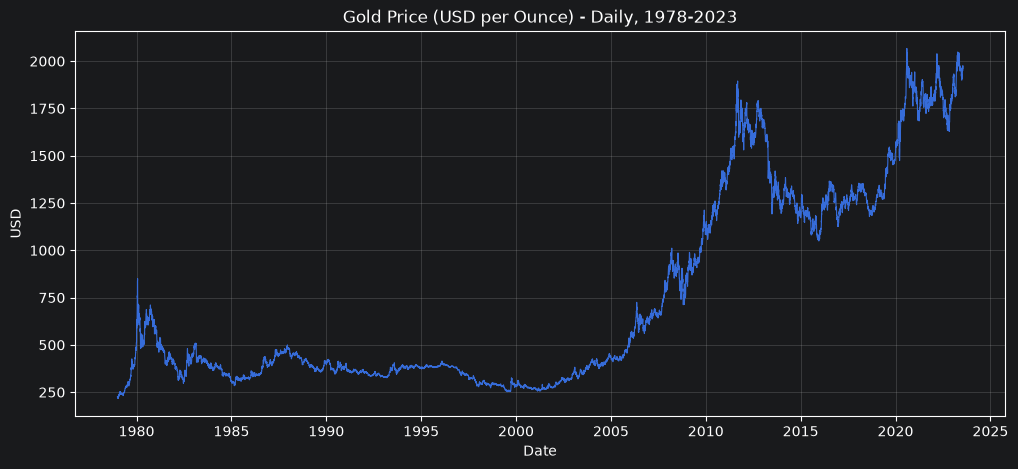

In [3]:
plt.plot(df.index, df["USD"], linewidth=0.8)
plt.title("Gold Price (USD per Ounce) - Daily, 1978-2023")
plt.xlabel("Date")
plt.ylabel("USD")
plt.grid(alpha=0.3)
plt.show()

**Observation:** A clear long-term upward trend with sharp volatility spikes
around 1980, 2008, 2011-2012, and 2020. This visual trend is the first sign
of non-stationarity, confirmed statistically below.

## 3. Stationarity Testing (ADF)

In [4]:
def run_adf(series, label):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.6f}")
    verdict = "STATIONARY" if result[1] < 0.05 else "NON-STATIONARY"
    print(f"Verdict       : {verdict}\n")
    return result[1]

run_adf(df["USD"], "Raw USD Price")

--- ADF Test: Raw USD Price ---
ADF Statistic : 0.3882
p-value       : 0.981048
Verdict       : NON-STATIONARY



np.float64(0.9810483447424622)

p-value is close to 1.0 - we fail to reject the null hypothesis of a unit root.
The raw price series is non-stationary, as expected. Next, we transform to log returns.

## 4. Log Returns Transformation

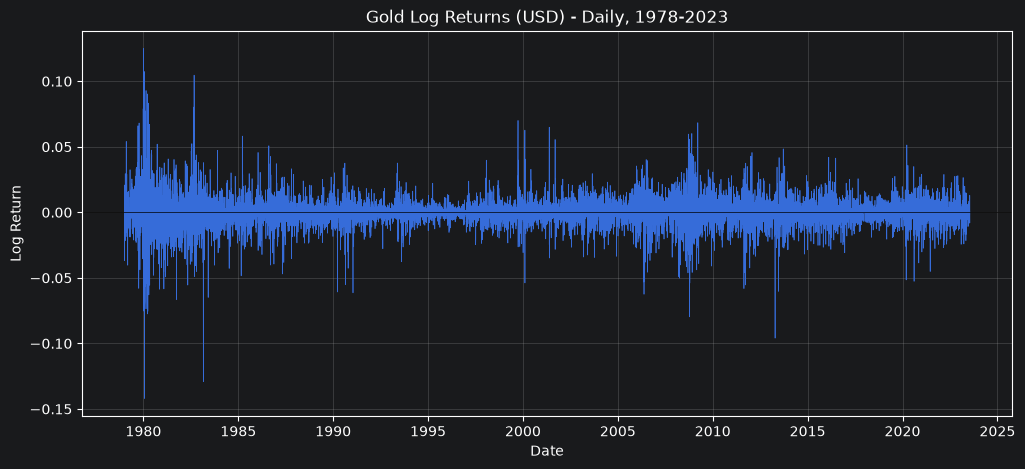

--- ADF Test: Log Returns ---
ADF Statistic : -23.7807
p-value       : 0.000000
Verdict       : STATIONARY



0.0

In [5]:
returns_df = add_log_returns(df)

plt.plot(returns_df.index, returns_df["log_return"], linewidth=0.5)
plt.axhline(0, color="black", linewidth=0.5)
plt.title("Gold Log Returns (USD) - Daily, 1978-2023")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(alpha=0.3)
plt.show()

run_adf(returns_df["log_return"], "Log Returns")

**Result:** After log-return transformation, the ADF p-value drops to
approximately 0.00 - we confidently reject the null hypothesis. The series
is now stationary and suitable for ARIMA-family modeling.

Note the volatility clustering visible in the plot - tighter bands in calm
periods (1990s-2000s) and wider bands during crises (1980, 2008, 2020).

## 5. ACF / PACF Analysis

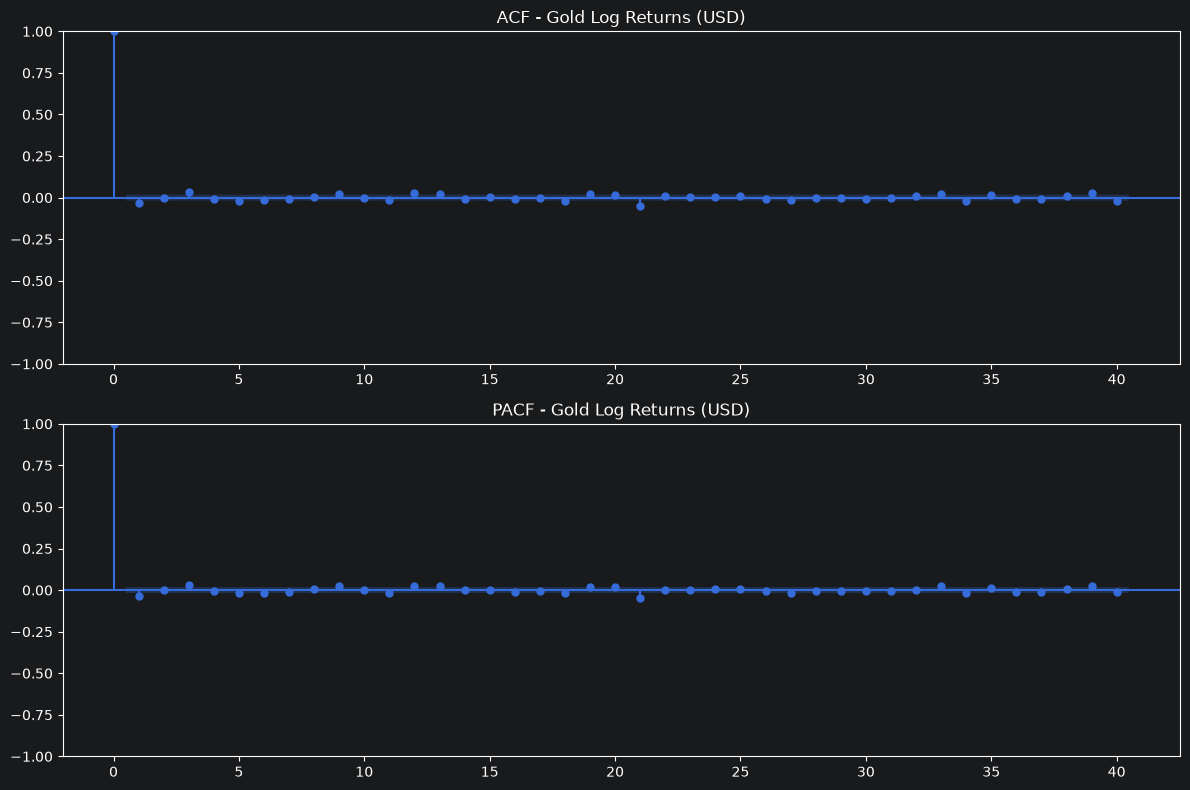

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(returns_df["log_return"], lags=40, ax=axes[0])
axes[0].set_title("ACF - Gold Log Returns (USD)")

plot_pacf(returns_df["log_return"], lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF - Gold Log Returns (USD)")

plt.tight_layout()
plt.show()

**Interpretation:** All lags (beyond lag 0) fall within the confidence band
in both ACF and PACF - a classic near-white-noise pattern. This suggests:

- Suggested initial ARIMA order: `p ≈ 0`, `d = 1` (already differenced via log returns), `q ≈ 0`
- A reasonable starting model is **ARIMA(0,1,0)**, with small variations like
  ARIMA(1,1,1) tested for marginal improvement

This white-noise-like behavior in returns is consistent with the **Random Walk
Hypothesis** for gold prices - confirmed further in the model comparison phase
(see `src/train_arima.py`, `src/compare_models.py`, and the main project README).

## Summary

| Step | Finding |
|---|---|
| Raw price | Non-stationary (ADF p ≈ 0.98) |
| Log returns | Stationary (ADF p ≈ 0.00) |
| ACF/PACF on returns | Near white noise - no strong autocorrelation structure |
| Implication | Gold's daily price closely follows a Random Walk |

Full model comparison (11 models, baseline through LSTM/XGBoost/Prophet) is in
`src/compare_models.py` and summarized in the project `README.md`.